# Comparative Analysis of Machine Learning and Deep Learning Models for Mushroom Binary Classification
<!-- # Mushroom Dataset (Binary Classification) using Machine Learning and Deep Learning Models -->

## Importing required Libraries and Loading the Dataset along with Exploratory Data Analysis (EDA)

In [206]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# splitting dataset into train and test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#see if i need it 
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay, classification_report , accuracy_score , precision_score , f1_score, recall_score

In [207]:
# loading the dataset
df = pd.read_csv(r"C:\Users\Asus\Downloads\mushroom_cleaned.csv")
df.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


In [208]:
df.shape

(54035, 9)

we have 54035 rows (records) and 9 columns (features)

In [209]:
df.columns

Index(['cap-diameter', 'cap-shape', 'gill-attachment', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'season', 'class'],
      dtype='object')

In [210]:
df.info() # to verify the type of the features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54035 entries, 0 to 54034
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cap-diameter     54035 non-null  int64  
 1   cap-shape        54035 non-null  int64  
 2   gill-attachment  54035 non-null  int64  
 3   gill-color       54035 non-null  int64  
 4   stem-height      54035 non-null  float64
 5   stem-width       54035 non-null  int64  
 6   stem-color       54035 non-null  int64  
 7   season           54035 non-null  float64
 8   class            54035 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.7 MB


In [211]:
df.describe()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
count,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000
mean,567.257204,4.000315,2.142056,7.329509,0.759110,1051.081299,8.418062,0.952163,0.549181
std,359.883763,2.160505,2.228821,3.200266,0.650969,782.056076,3.262078,0.305594,0.497580
min,0.000000,0.000000,0.000000,0.000000,0.000426,0.000000,0.000000,0.027372,0.000000
25%,289.000000,2.000000,0.000000,5.000000,0.270997,421.000000,6.000000,0.888450,0.000000
50%,525.000000,5.000000,1.000000,8.000000,0.593295,923.000000,11.000000,0.943195,1.000000
75%,781.000000,6.000000,4.000000,10.000000,1.054858,1523.000000,11.000000,0.943195,1.000000
max,1891.000000,6.000000,6.000000,11.000000,3.835320,3569.000000,12.000000,1.804273,1.000000


#### 1- Class Distribution

In [212]:
# number of values in each class
target_counts = df['class'].value_counts()
print(target_counts)

class
1    29675
0    24360
Name: count, dtype: int64


we have more poisonous mushrooms than edible ones we plot to see their distribution, the data is relatively balanced

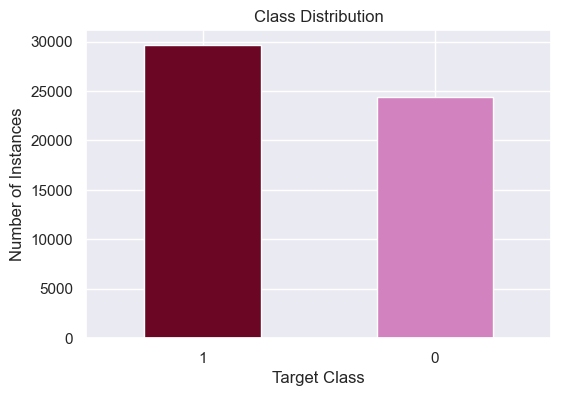

In [213]:
# Plot the bar graph
plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar', color=['#6B0725', '#D283BF'])
plt.title('Class Distribution')
plt.xlabel('Target Class')
plt.ylabel('Number of Instances')
plt.xticks(rotation=0)
plt.show()

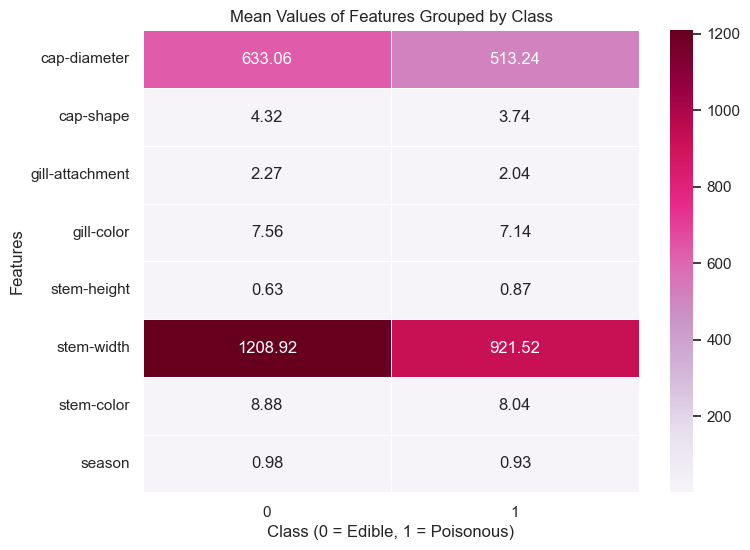

In [214]:
#Mean Feature Values by Class
# Group by 'class' and calculate mean values for each feature
class_feature_means = df.groupby('class').mean()

# Create a heatmap for the mean values of features by class
plt.figure(figsize=(8, 6))
sns.heatmap(class_feature_means.T, annot=True, cmap='PuRd', fmt=".2f", linewidths=0.5)
plt.title('Mean Values of Features Grouped by Class')
plt.xlabel('Class (0 = Edible, 1 = Poisonous)')
plt.ylabel('Features')
plt.show()

#### 2- Feature Correlation

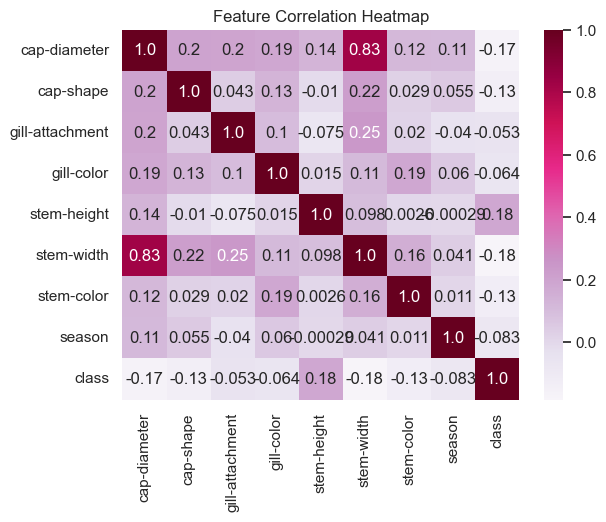

In [215]:
# heatmap for feature correlation 
sns.heatmap(df.corr(), annot=True, fmt='.2', cmap='PuRd')
plt.title('Feature Correlation Heatmap')
plt.show()

#### 3- Checking for outliers

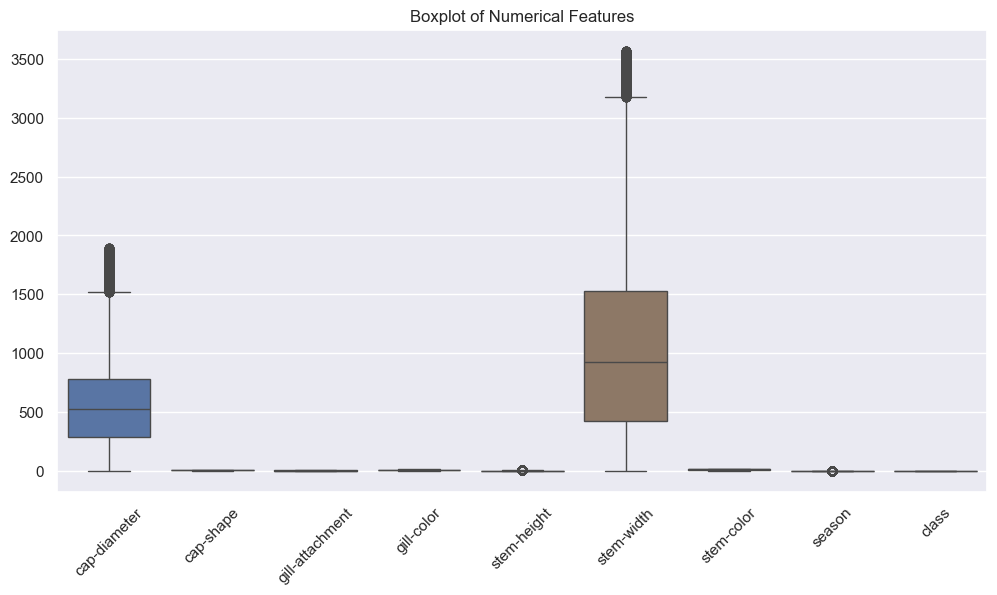

In [234]:
# Plot boxplots for all numerical features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [235]:
# Calculating Z-scores
z_scores = (df.select_dtypes(include=[np.number]) - df.mean()) / df.std()

# Detect outliers (Z-score > 3 or < -3)
outliers = (z_scores.abs() > 3).sum()
print(outliers) #The Z-score tells you how many standard deviations a data point is from the mean.
#A Z-score greater than 3 or less than -3 is often considered an outlier.


cap-diameter        499
cap-shape             0
gill-attachment       0
gill-color            0
stem-height         887
stem-width          222
stem-color            0
season             2219
class                 0
dtype: int64


In [236]:
print(df[['cap-diameter', 'stem-height', 'stem-width', 'season']].describe())


       cap-diameter   stem-height    stem-width        season
count  54035.000000  54035.000000  54035.000000  54035.000000
mean     567.257204      0.759110   1051.081299      0.952163
std      359.883763      0.650969    782.056076      0.305594
min        0.000000      0.000426      0.000000      0.027372
25%      289.000000      0.270997    421.000000      0.888450
50%      525.000000      0.593295    923.000000      0.943195
75%      781.000000      1.054858   1523.000000      0.943195
max     1891.000000      3.835320   3569.000000      1.804273


- cap-diameter: the boxplot shows some extreme values above 1500, meaning there are a few very large caps, Z-scores found 499 outliers, meaning many values are far from the mean and in describe() the Max = 1891 which is way above typical values and even the standard deviation (359.88) is large, meaning cap sizes vary a lot. Some mushrooms have exceptionally large caps, which might be natural variations and makes sense if these mushrooms belong to a specific species.
- stem height: doesn't show outliers in the box plot however zscores found 887 outliers, meaning many stems are longer than expected. in descibe() they showed a max of 3.83 while the mean is 1.08 so it's not too extreeme, the high values could just be naturally taller mushrooms.
- stem width: the boxplot shows severe outliers, especially near 3500, the Z-scores found 222 outliers, meaning there are extreme values. in describe() the Max = 3569 which is over double the 75th percentile ( Q3 = 1523) and the standard deviation (782) is very high, meaning stem widths vary a lot.
The extreme values could indicate measurement errors or unit mismatches (mm vs. cm) which will be corrected after scaling hopefully.

These extreme values indicating either measurement inconsistencies or natural biological variation. We do not remove them at this stage but acknowledge their presence for further analysis.

## Data Preprocessing

#### 1- Checking for any missing data

In [216]:
df.isnull().sum()  

cap-diameter       0
cap-shape          0
gill-attachment    0
gill-color         0
stem-height        0
stem-width         0
stem-color         0
season             0
class              0
dtype: int64

there are no missing values in our dataset so we are good to go 

In [237]:
#Duplicate value check
df.duplicated().sum()
# Display duplicated rows
duplicated_rows = df[df.duplicated()]
duplicated_rows.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
8815,69,6,0,10,1.206059,125,1,0.888450,1
11930,27,6,0,11,1.054858,24,12,0.888450,1
33640,204,0,0,5,0.154755,271,6,0.027372,1
50246,384,3,0,10,2.013794,0,2,0.888450,1
50290,382,3,0,10,2.013794,0,2,0.888450,1


#### 2- Splitting the dataset 

In [218]:
X=df.drop('class', axis=1) # Features (excluding the target column)
y=df['class'].values

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape) 
print("Test set shape:",X_test.shape)


Training set shape: (43228, 8)
Test set shape: (10807, 8)


#### 3- Feature Scaling
here the MinMax Scaler is used because it is preferred for deep learning models especially using Keras and as we are harmonizing our work across all models, even ML models can adapt to MinMaxScaler 

In [219]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()
# Fit the scaler to the training set and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Transform the test set using the same scaler (no fitting, only transforming)
X_test_scaled = scaler.transform(X_test)

## Models Training and Evaluation

#### 1- Machine Learning models
We will work on these 5 machine learning models

In [220]:
models ={
    'KNN':KNeighborsClassifier(),
    'Gauss_NB':GaussianNB(),
    'Logistic_Regression':LogisticRegression(),
    'Decision_Tree': DecisionTreeClassifier(),
    'Random_Forest_Classifier':RandomForestClassifier()
}

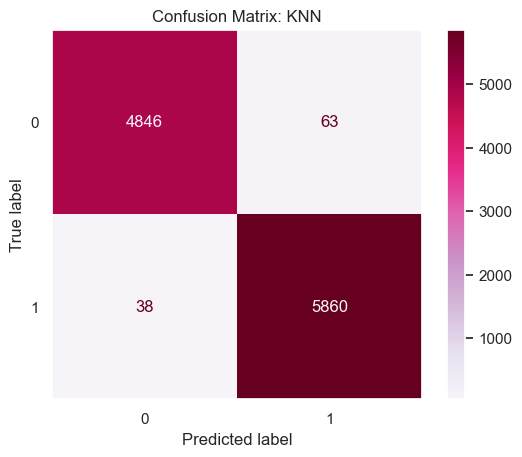

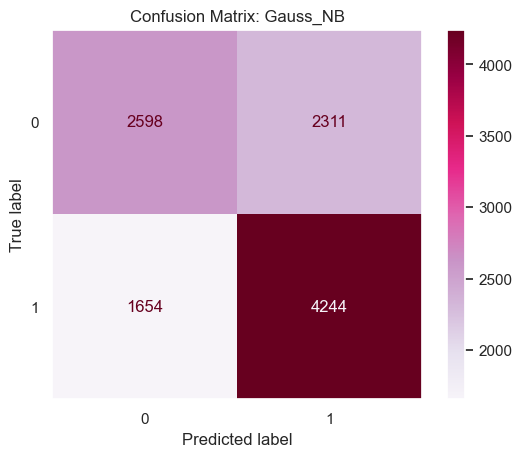

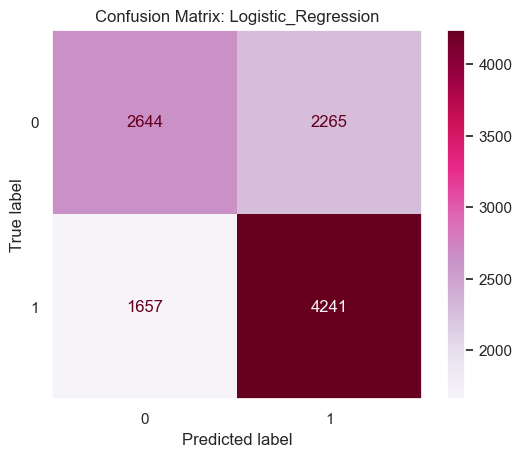

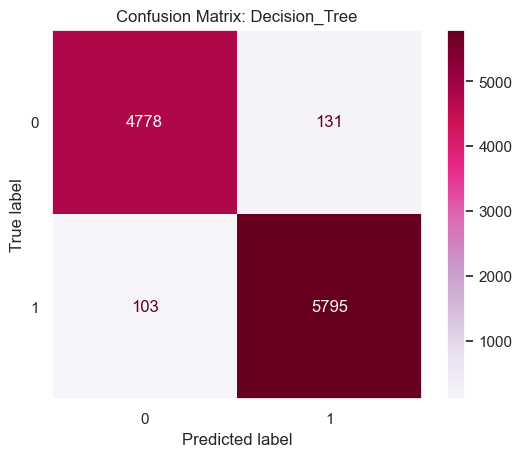

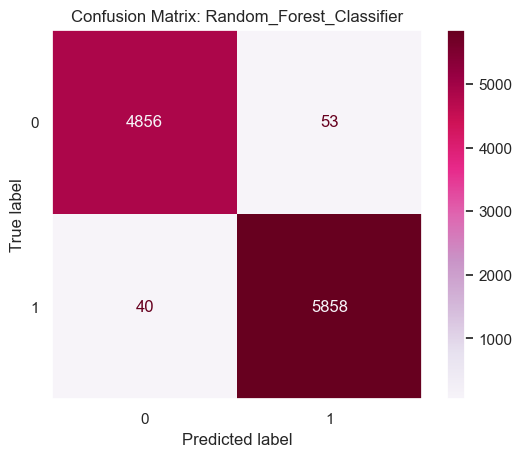

                      Model  Accuracy  Precision    Recall  F1-Score
0                       KNN  0.990654   0.989363  0.993557  0.991456
1                  Gauss_NB  0.633108   0.647445  0.719566  0.681603
2       Logistic_Regression  0.637087   0.651860  0.719057  0.683812
3             Decision_Tree  0.978347   0.977894  0.982536  0.980210
4  Random_Forest_Classifier  0.991394   0.991034  0.993218  0.992125


In [221]:
# Dictionary to store results
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

# Evaluate each model
for i in models:
    obj = models[i]
    obj.fit(X_train_scaled, y_train)
    obj_pred = obj.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, obj_pred)
    precision = precision_score(y_test, obj_pred)
    recall = recall_score(y_test, obj_pred)
    f1 = f1_score(y_test, obj_pred)

    # Store results in the dictionary
    results['Model'].append(i)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1-Score'].append(f1)

    # Plot confusion matrix
    cm = confusion_matrix(y_test, obj_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=obj.classes_ if hasattr(obj, 'classes_') else [0, 1])
    disp.plot(cmap='PuRd', values_format='d')
    plt.grid(False)
    plt.title(f'Confusion Matrix: {i}')
    plt.show()

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display the results in a table
print(results_df)

#### 2- Deep Learning models
We will work on the following deep learning models

##### ANN: we begin by the artificial neural networks model to perform binary classification on the dataset. The ANN will be trained to predict the output based on 8 input features

In [222]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam

model = Sequential() #sequential is like the architecture of the network
# #hidden layers
# model.add(Dense(8,input_dim=8,activation="relu"))

# model.add(Dense(8,activation="relu"))

# hidden layer
model.add(Dense(32,input_dim=8,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(32,activation="relu"))

#output layer
model.add(Dense(1,activation="sigmoid")) 

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [223]:
model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_77 (Dense)                     │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_78 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_79 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_80 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_81 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

In [224]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

model.fit(X_train_scaled, y_train, epochs=64,batch_size=128,  verbose=2)

Epoch 1/64
338/338 - 4s - 13ms/step - accuracy: 0.6660 - loss: 0.5922
Epoch 2/64
338/338 - 1s - 2ms/step - accuracy: 0.7817 - loss: 0.4496
Epoch 3/64
338/338 - 1s - 2ms/step - accuracy: 0.8548 - loss: 0.3349
Epoch 4/64
338/338 - 1s - 2ms/step - accuracy: 0.8887 - loss: 0.2708
Epoch 5/64
338/338 - 1s - 2ms/step - accuracy: 0.9032 - loss: 0.2380
Epoch 6/64
338/338 - 1s - 2ms/step - accuracy: 0.9185 - loss: 0.2077
Epoch 7/64
338/338 - 1s - 2ms/step - accuracy: 0.9259 - loss: 0.1903
Epoch 8/64
338/338 - 1s - 2ms/step - accuracy: 0.9347 - loss: 0.1705
Epoch 9/64
338/338 - 1s - 2ms/step - accuracy: 0.9417 - loss: 0.1563
Epoch 10/64
338/338 - 1s - 2ms/step - accuracy: 0.9444 - loss: 0.1473
Epoch 11/64
338/338 - 1s - 3ms/step - accuracy: 0.9488 - loss: 0.1376
Epoch 12/64
338/338 - 1s - 2ms/step - accuracy: 0.9486 - loss: 0.1364
Epoch 13/64
338/338 - 1s - 3ms/step - accuracy: 0.9535 - loss: 0.1234
Epoch 14/64
338/338 - 1s - 4ms/step - accuracy: 0.9574 - loss: 0.1137
Epoch 15/64
338/338 - 1s - 2

In [225]:
score = model.evaluate(X_test_scaled, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.05542067438364029
Test accuracy: 0.9769594073295593


338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  Model  Accuracy  Precision    Recall  F1-Score
0   ANN  0.976959   0.978323  0.979485  0.978904


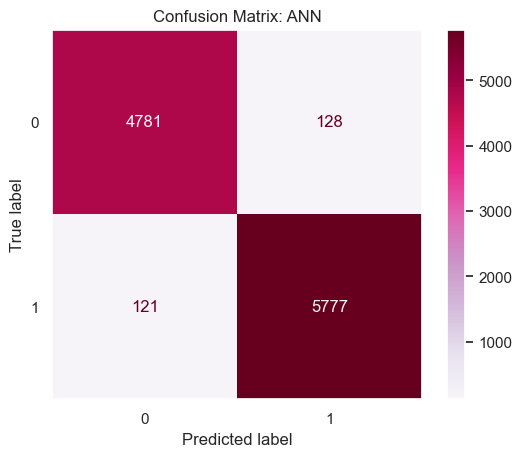

In [226]:
# Generate predictions
y_pred_probs = model.predict(X_test_scaled)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)    # Convert to binary class predictions

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store results in a dictionary
results = {
    'Model': ['ANN'],  
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='PuRd', values_format='d')
plt.grid(False)
plt.title('Confusion Matrix: ANN')
plt.show()

##### CNN: 

CNNs are typically designed to handle spatial data (images) where each sample is processed by applying filters across different channels (such as RGB for images). In our case of mushroom data which has multiple features, CNN will treat each feature as a separate channel. 
For CNN we are reshaping the data as (samples, features, 1) which allow it to apply convolutional filters across the features, capturing potential local patterns or relationships between adjacent features (e.g., cap diameter and stem width) where samples is the number of individual data points in the dataset, the 8 features describing each mushroom sample, and 1 is the number of channels, since each feature is treated as an individual value.
Since our input Shape is (samples, features, 1) → each sample has 8 features treated as a 1D sequence, The 1D convolutional filter slides across the features, learning patterns helping detect feature relationships which is ideal for our sequence-like numerical data.

In [228]:
# Reshape the input data to 3D for CNN (batch_size, features, 1)
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], 8, 1))  # Reshaping to 3D
X_test_cnn =  X_test_scaled.reshape((X_test_scaled.shape[0], 8, 1))
  # Reshaping to 3D
model = Sequential()

# Reshape the input data into 2D for CNN (number of features x 1)
# Assuming you have 8 features, we reshape it to (8, 1) for 1D CNN
model.add(Conv1D(64, kernel_size=2, activation='relu', input_shape=(8, 1)))  # 64 filters, kernel size 2
model.add(MaxPooling1D(pool_size=2))  # Pooling layer to reduce dimensionality
model.add(Conv1D(128, kernel_size=2, activation='relu'))  # Second convolutional layer with more filters
model.add(MaxPooling1D(pool_size=2))  # Pooling layer

# Flatten the output from the convolutional layers before passing to fully connected layers
model.add(Flatten())

# Fully connected (Dense) layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))  # Dropout layer to reduce overfitting
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Summarize the model
model.summary()

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_cnn, y_train, epochs=64,batch_size=128,  verbose=2)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)                   │ (None, 7, 64)               │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_21 (MaxPooling1D)      │ (None, 3, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_22 (Conv1D)                   │ (None, 2, 128)              │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_22 (MaxPooling1D)      │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_11 (Flatten)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_85 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_86 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_87 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,073 (105.75 KB)

 Trainable params: 27,073 (105.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/64
338/338 - 4s - 12ms/step - accuracy: 0.6369 - loss: 0.6281
Epoch 2/64
338/338 - 2s - 5ms/step - accuracy: 0.7359 - loss: 0.5249
Epoch 3/64
338/338 - 1s - 4ms/step - accuracy: 0.8105 - loss: 0.4120
Epoch 4/64
338/338 - 2s - 5ms/step - accuracy: 0.8522 - loss: 0.3346
Epoch 5/64
338/338 - 2s - 5ms/step - accuracy: 0.8780 - loss: 0.2850
Epoch 6/64
338/338 - 2s - 5ms/step - accuracy: 0.8920 - loss: 0.2502
Epoch 7/64
338/338 - 1s - 4ms/step - accuracy: 0.9030 - loss: 0.2291
Epoch 8/64
338/338 - 1s - 4ms/step - accuracy: 0.9102 - loss: 0.2132
Epoch 9/64
338/338 - 1s - 4ms/step - accuracy: 0.9194 - loss: 0.1960
Epoch 10/64
338/338 - 1s - 4ms/step - accuracy: 0.9257 - loss: 0.1832
Epoch 11/64
338/338 - 3s - 8ms/step - accuracy: 0.9313 - loss: 0.1702
Epoch 12/64
338/338 - 1s - 4ms/step - accuracy: 0.9326 - loss: 0.1661
Epoch 13/64
338/338 - 1s - 4ms/step - accuracy: 0.9342 - loss: 0.1600
Epoch 14/64
338/338 - 1s - 3ms/step - accuracy: 0.9378 - loss: 0.1559
Epoch 15/64
338/338 - 1s - 3

In [229]:
score = model.evaluate(X_test_cnn, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.05001946538686752
Test accuracy: 0.9815859794616699


338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Model  Accuracy  Precision    Recall  F1-Score
0   CNN  0.981586   0.976904  0.989658  0.983239


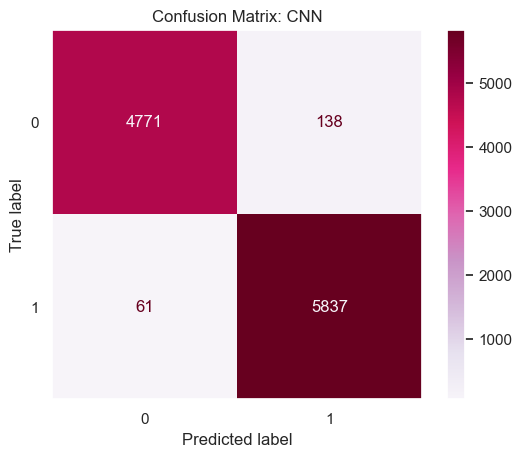

In [230]:
# Generate predictions
y_pred_probs = model.predict(X_test_cnn)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)    # Convert to binary class predictions

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store results in a dictionary
results = {
    'Model': ['CNN'],  
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='PuRd', values_format='d')
plt.grid(False)
plt.title('Confusion Matrix: CNN')
plt.show()

we achieved better results that CNN, which is impressive given the fact that this isn't a typical case for CNN (since we're not working with images)

##### RNN: 

RNNs are designed for sequential data, where each data point depends on the previous ones. Although our mushroom dataset is not temporal, reshaping it into a sequence allows the RNN to process each feature as part of a sequence. For RNN we are reshaping the data as (samples, 1, features), the model will process each sample as a sequence with 1 timestep and 8 features where samples is the number of individual data points, 1 is the number of timesteps ( here each sample has 1 timestep (i.e., a single observation), and 8 as the number of features at that timestep.
Unlike CNNs, RNNs process data sequentially so they expect the timesteps to come first in the input shape, because that's how the network understands which part of the sequence it is currently processing.
Also we are leveraging LSTM's ability to learn patterns in feature interactions that's why we added the layer of LSTM.


In [231]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Reshape the input data to 3D for RNN (samples, timesteps, features)
# For mushroom data, we reshape it to (samples, 1, 8) since we have 8 features
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, 8))  # Reshaping to 3D
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, 8))  # Reshaping to 3D

# Create the model
model = Sequential()

# Add the LSTM layer
model.add(LSTM(64, input_shape=(1, 8), activation='relu', return_sequences=False))  # LSTM layer with 64 units
model.add(Dropout(0.5))  # Dropout layer to reduce overfitting

# Add a Dense layer
model.add(Dense(32, activation='relu'))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Summarize the model
model.summary()

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_rnn, y_train, epochs=50, batch_size=128, verbose=2)

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 64)                  │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_88 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_89 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
338/338 - 6s - 17ms/step - accuracy: 0.6032 - loss: 0.6537
Epoch 2/50
338/338 - 1s - 3ms/step - accuracy: 0.6682 - loss: 0.6022
Epoch 3/50
338/338 - 2s - 5ms/step - accuracy: 0.6922 - loss: 0.5734
Epoch 4/50
338/338 - 2s - 4ms/step - accuracy: 0.7085 - loss: 0.5529
Epoch 5/50
338/338 - 2s - 5ms/step - accuracy: 0.7202 - loss: 0.5362
Epoch 6/50
338/338 - 2s - 6ms/step - accuracy: 0.7277 - loss: 0.5273
Epoch 7/50
338/338 - 1s - 3ms/step - accuracy: 0.7329 - loss: 0.5211
Epoch 8/50
338/338 - 1s - 3ms/step - accuracy: 0.7408 - loss: 0.5120
Epoch 9/50
338/338 - 1s - 3ms/step - accuracy: 0.7446 - loss: 0.5052
Epoch 10/50
338/338 - 1s - 3ms/step - accuracy: 0.7493 - loss: 0.4990
Epoch 11/50
338/338 - 1s - 3ms/step - accuracy: 0.7510 - loss: 0.4954
Epoch 12/50
338/338 - 1s - 3ms/step - accuracy: 0.7542 - loss: 0.4908
Epoch 13/50
338/338 - 1s - 3ms/step - accuracy: 0.7618 - loss: 0.4829
Epoch 14/50
338/338 - 1s - 3ms/step - accuracy: 0.7612 - loss: 0.4823
Epoch 15/50
338/338 - 1s - 3

In [232]:
score = model.evaluate(X_test_rnn, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.3131716549396515
Test accuracy: 0.8712871074676514


338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Model  Accuracy  Precision    Recall  F1-Score
0   RNN  0.871287   0.901479  0.857918  0.879159


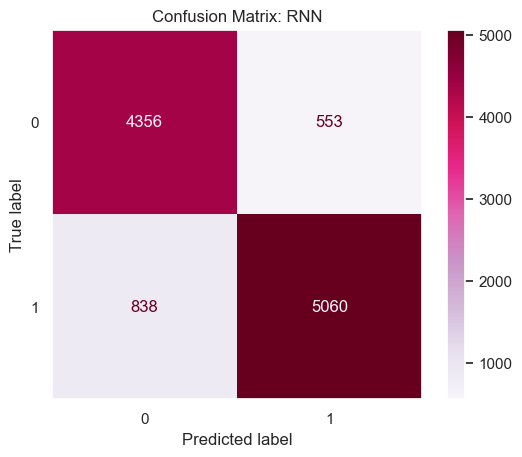

In [233]:
# Generate predictions
y_pred_probs = model.predict(X_test_rnn)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)    # Convert to binary class predictions

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store results in a dictionary
results = {
    'Model': ['RNN'],  
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='PuRd', values_format='d')
plt.grid(False)
plt.title('Confusion Matrix: RNN')
plt.show()

RNN achieved decent results given the fact that it's not the best choice for this mushroom classification task (it performs well with sequential data )